# Hands-On 3: Neighbourhoods and classification

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from mlcourse.labs import compare_boundaries, split_classification
from mlcourse.widgets import interactive_knn

## 1. Inspect Iris

Load the Iris dataset into a dataframe. Inspect its content with `head()` and `describe()`.

**Prediction:** Which columns can locate an observation in feature space?

The four measurements can locate each observation; the species label is the target.

In [3]:
iris = load_course_data('iris')
display(iris.head())
display(iris.describe())
display(iris.Species.value_counts().rename('count'))

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.100,3.500,1.400,0.200,Iris-setosa
1,4.900,3.000,1.400,0.200,Iris-setosa
2,4.700,3.200,1.300,0.200,Iris-setosa
3,4.600,3.100,1.500,0.200,Iris-setosa
4,5.000,3.600,1.400,0.200,Iris-setosa


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

**Observation:** How many measurements and classes are present?

The preview shows four numeric measurements and three species. The class-count table makes their representation visible.

**Explanation:** Why should the species label be excluded from the predictors?

Using the species label as an input would reveal the answer. Classification must use measurements available before that answer is known.

## 2. Fit a neighbour classifier

Split the four measurements into training and test data. Fit scaled `KNeighborsClassifier(n_neighbors=5)`.

**Prediction:** How might unequal measurement scales change the nearest neighbours?

A measurement with a larger numerical range can dominate distances. Scaling changes the relative contribution of each coordinate.

Test accuracy: 0.978


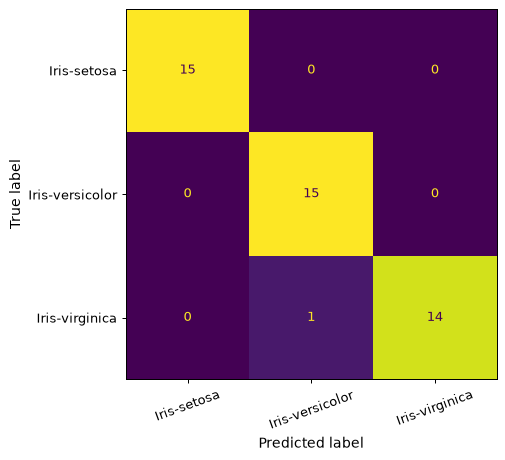

In [4]:
X = iris.drop(columns='Species')
y = iris.Species
X_train, X_test, y_train, y_test = split_classification(X, y)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
knn.fit(X_train, y_train)
print(f'Test accuracy: {accuracy_score(y_test, knn.predict(X_test)):.3f}')
fig, ax = plt.subplots(figsize=(7, 5), layout='constrained')
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, ax=ax, colorbar=False, xticks_rotation=20)
plt.show()

**Observation:** Which off-diagonal entries contain errors?

One Iris-virginica observation is predicted as Iris-versicolor. All other off-diagonal counts are zero, giving test accuracy 0.978.

**Explanation:** Relate those errors to overlapping neighbourhoods.

Nearby observations can belong to different classes. A majority vote smooths this local ambiguity but cannot remove overlap in the measured feature space.

## 3. Compare two fixed boundaries

Use sepal measurements only. Compare `n_neighbors=1` with `n_neighbors=15` on the same split.

**Prediction:** Which boundary will be more sensitive to individual observations?

The `n_neighbors=1` boundary should react more strongly to individual points.

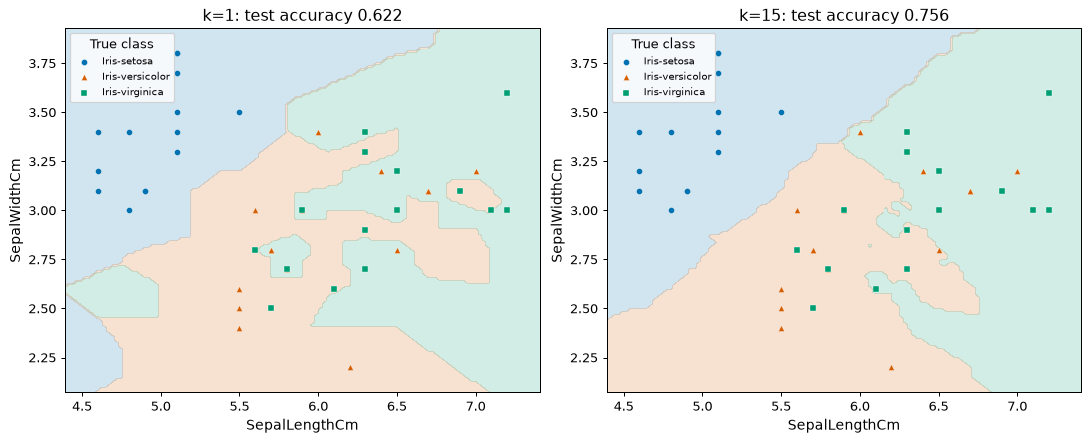

,train_accuracy,test_accuracy
model,,
k=1,0.943,0.622
k=15,0.800,0.756


In [5]:
X2 = iris[['SepalLengthCm', 'SepalWidthCm']]
X2_train, X2_test, y2_train, y2_test = split_classification(X2, y)
comparison = compare_boundaries({
    'k=1': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)),
    'k=15': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
}, X2_train, X2_test, y2_train, y2_test)
display(comparison)

**Observation:** Compare boundary detail and the two accuracy columns.

With `n_neighbors=1`, train/test accuracy is 0.943/0.622 and the boundary contains small local regions. With `n_neighbors=15`, it becomes smoother and the scores are 0.800/0.756.

**Explanation:** How does neighbourhood size change local sensitivity and smoothing?

Larger neighbourhoods pool more labels and reduce local sensitivity. Excessive pooling can cross class regions and increase bias.

## 4. Manipulate the neighbourhood

Change `n_neighbors` from `1` to `31`, then compare uniform and distance weighting.

**Prediction:** At which end of the range do you expect the smoothest boundary?

The largest neighbourhood should give the broadest smoothing. Distance weighting may retain more local influence.

In [ ]:
knn_lab = interactive_knn(X2_train, X2_test, y2_train, y2_test)
display(knn_lab.widget)

**Observation:** Record one setting that changes a local region and its test accuracy.

Increasing uniform-weighted `n_neighbors` from `5` to `31` broadens the regions and changes test accuracy from 0.756 to 0.733. At `31`, distance weighting changes the local votes and gives 0.689.

**Explanation:** Explain the change using neighbour votes and distance weighting.

Uniform weighting counts every selected neighbour equally. Distance weighting gives nearby labels more influence, so the same neighbourhood can produce a different vote.

## 5. Compare inductive biases

Fit a linear discriminant model, Gaussian Naive Bayes and a shallow tree on `ds2`.

**Prediction:** Which model can form axis-aligned regions?

The tree can form axis-aligned regions by splitting one coordinate at a time.

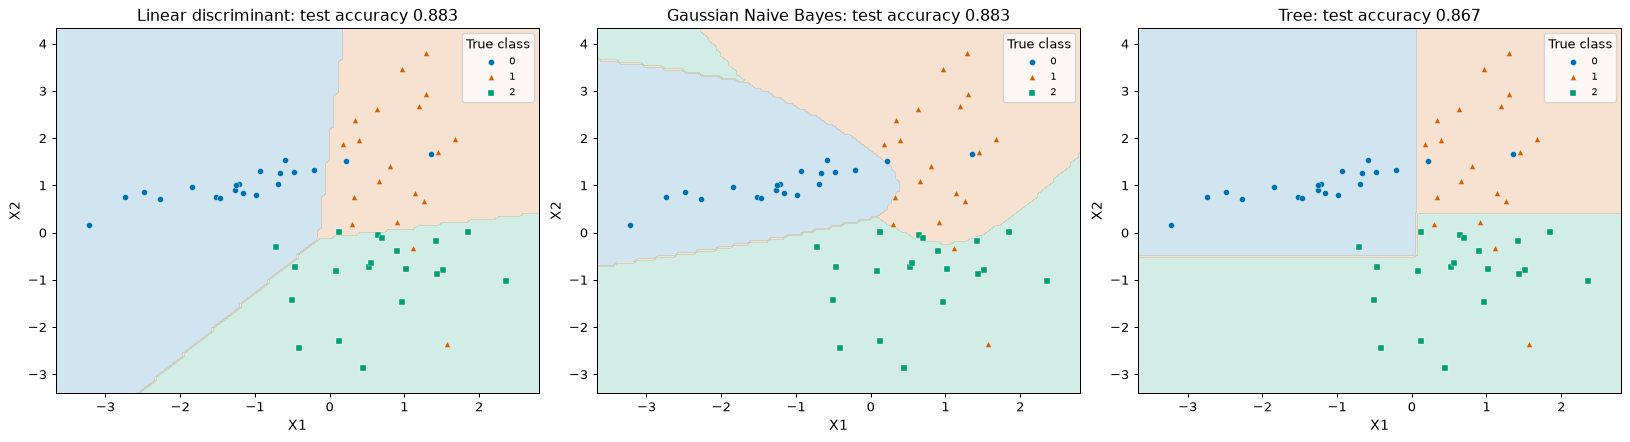

,train_accuracy,test_accuracy
model,,
Linear discriminant,0.829,0.883
Gaussian Naive Bayes,0.850,0.883
Tree,0.886,0.867


In [7]:
data = load_course_data('ds2')
a, b, c, d = split_classification(data[['X1', 'X2']], data.Class)
display(compare_boundaries({'Linear discriminant': LinearDiscriminantAnalysis(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Tree': DecisionTreeClassifier(max_depth=3, random_state=0)}, a, b, c, d))

**Observation:** Compare the shapes of the three boundaries.

The discriminant boundaries are straight, the Naive Bayes boundaries curve, and the tree uses axis-aligned steps. Their test accuracies are 0.883, 0.883 and 0.867 respectively.

**Explanation:** Which restrictions does each model place on the classification rule?

Linear discriminant analysis uses linear separating boundaries. Gaussian Naive Bayes combines class-conditional feature densities under conditional independence, while the tree builds rectangular partitions.